# Split CIFAR-100 Benchmark — Adaptive Consolidation with Intentional Forgetting

**CpE 620 — Spring 2026**

This notebook evaluates continual learning on a five-task Split CIFAR-100 benchmark using
non-overlapping 10-class tasks. It compares sequential fine-tuning, EWC, Synaptic Intelligence,
and the proposed adaptive consolidation with intentional forgetting method.

This portfolio copy preserves the original experimental logic and saved results while removing
nonessential presentation-only material.


In [ ]:
# ============================================================
# CELL 1 — Setup
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import random
import matplotlib.pyplot as plt
from copy import deepcopy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# ============================================================
# CELL 2 — CIFAR-100 transforms and loading
# ============================================================
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_transform)
test_ds  = datasets.CIFAR100(root="./data", train=False, download=True, transform=test_transform)

print("Train size:", len(train_ds))
print("Test size :", len(test_ds))

Train size: 50000
Test size : 10000


In [ ]:
# ============================================================
# CELL 3 — Split CIFAR-100 into 5 tasks x 10 classes each
# ============================================================
num_tasks = 5
classes_per_task = 10

task_class_splits = []
for t in range(num_tasks):
    start = t * classes_per_task
    end = start + classes_per_task
    task_class_splits.append(list(range(start, end)))

for t, cls in enumerate(task_class_splits):
    print(f"Task {t}: {cls}")

Task 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Task 1: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Task 2: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Task 3: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Task 4: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [ ]:
# ============================================================
# CELL 4 — Create task-specific subsets and loaders
# ============================================================
def filtered_indices(dataset, allowed_labels):
    return [i for i, (_, y) in enumerate(dataset) if int(y) in allowed_labels]

train_task_subsets = []
test_task_subsets = []

for task_id, task_classes in enumerate(task_class_splits):
    train_idx = filtered_indices(train_ds, set(task_classes))
    test_idx  = filtered_indices(test_ds, set(task_classes))

    train_task_subsets.append(Subset(train_ds, train_idx))
    test_task_subsets.append(Subset(test_ds, test_idx))

batch_size = 128

train_loaders = [
    DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    for ds in train_task_subsets
]

test_loaders = [
    DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    for ds in test_task_subsets
]

for t in range(num_tasks):
    print(f"Task {t}: train={len(train_task_subsets[t])}, test={len(test_task_subsets[t])}")

Task 0: train=5000, test=1000
Task 1: train=5000, test=1000
Task 2: train=5000, test=1000
Task 3: train=5000, test=1000
Task 4: train=5000, test=1000


In [ ]:
# ============================================================
# CELL 5 — Label remapping for task-aware heads
# ============================================================
def remap_labels(y, task_id):
    y = y.clone()
    offset = task_id * classes_per_task
    return y - offset

In [ ]:
# ============================================================
# CELL 6 — Shared backbone + task-specific heads
# ============================================================
class CIFARFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 -> 8

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 8 -> 4
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x


class MultiHeadNet(nn.Module):
    def __init__(self, num_tasks=5, classes_per_task=10):
        super().__init__()
        self.backbone = CIFARFeatureExtractor()
        self.heads = nn.ModuleList([
            nn.Linear(512, classes_per_task) for _ in range(num_tasks)
        ])

    def forward(self, x, task_id):
        feats = self.backbone(x)
        return self.heads[task_id](feats)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MultiHeadNet(num_tasks=num_tasks, classes_per_task=classes_per_task).to(device)
print("Trainable params:", count_params(model))

Trainable params: 2679922


In [ ]:
# ============================================================
# CELL 7 — Evaluation utilities
# ============================================================
@torch.no_grad()
def evaluate_task(model, loader, task_id):
    model.eval()
    total, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        logits = model(x, task_id)
        pred = logits.argmax(dim=1)

        total += y_t.size(0)
        correct += (pred == y_t).sum().item()

    return correct / total


def evaluate_seen_tasks(model, seen_tasks):
    return [evaluate_task(model, test_loaders[t], t) for t in seen_tasks]


def print_seen_task_summary(model, seen_tasks, note=""):
    accs = evaluate_seen_tasks(model, seen_tasks)
    mean_acc = np.mean(accs) if len(accs) > 0 else 0.0
    print(
        f"{note} | " +
        ", ".join([f"T{t}:{accs[i]:.4f}" for i, t in enumerate(seen_tasks)]) +
        f" | Mean:{mean_acc:.4f}"
    )
    return accs, mean_acc

In [ ]:
# ============================================================
# CELL 8 — Training helpers
# ============================================================
def set_trainable(model, train_backbone=True, train_heads=None):
    for p in model.backbone.parameters():
        p.requires_grad = train_backbone

    if train_heads is None:
        for head in model.heads:
            for p in head.parameters():
                p.requires_grad = True
    else:
        for i, head in enumerate(model.heads):
            flag = i in train_heads
            for p in head.parameters():
                p.requires_grad = flag


def get_optimizer(model, lr=1e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

In [ ]:
# ============================================================
# CELL 9 — Metrics utilities
# ============================================================
def compute_forgetting(acc_matrix):
    forgetting_per_task = {}
    final_row = acc_matrix[-1]

    for task_j in range(len(final_row)):
        prev = [acc_matrix[i][task_j] for i in range(len(acc_matrix)) if acc_matrix[i][task_j] is not None]
        if len(prev) == 0:
            continue
        best_before_final = max(prev[:-1]) if len(prev) > 1 else prev[0]
        final_acc = final_row[task_j]
        forgetting_per_task[task_j] = best_before_final - final_acc

    mean_forgetting = np.mean(list(forgetting_per_task.values()))
    return forgetting_per_task, mean_forgetting

In [ ]:
# ============================================================
# CELL 10 — EWC helpers
# ============================================================
def snapshot_backbone(model):
    return {n: p.detach().clone() for n, p in model.backbone.named_parameters()}

def compute_fisher_diag_backbone(model, data_loader, task_id, num_batches=100):
    model.eval()

    fisher = {
        n: torch.zeros_like(p, device=device)
        for n, p in model.backbone.named_parameters()
    }

    count = 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        model.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)
        loss.backward()

        for n, p in model.backbone.named_parameters():
            if p.grad is not None:
                fisher[n] += (p.grad.detach() ** 2)

        count += 1
        if count >= num_batches:
            break

    for n in fisher:
        fisher[n] /= max(count, 1)

    return fisher


class EWCBackbone:
    def __init__(self, fisher, theta_old, lam=500.0):
        self.fisher = fisher
        self.theta_old = theta_old
        self.lam = lam

    def penalty(self, model):
        loss = 0.0
        for n, p in model.backbone.named_parameters():
            loss += (self.fisher[n] * (p - self.theta_old[n]) ** 2).sum()
        return self.lam * loss

In [ ]:
# ============================================================
# CELL 11 — SI (Synaptic Intelligence) helpers
# ============================================================
class SIRegularizer:
    def __init__(self, model, si_c=0.5, epsilon=0.1):
        self.si_c = si_c
        self.epsilon = epsilon

        self.prev_params = {
            n: p.detach().clone()
            for n, p in model.backbone.named_parameters()
        }

        self.omega = {
            n: torch.zeros_like(p, device=device)
            for n, p in model.backbone.named_parameters()
        }

        self.W = {
            n: torch.zeros_like(p, device=device)
            for n, p in model.backbone.named_parameters()
        }

        self.task_start_params = {
            n: p.detach().clone()
            for n, p in model.backbone.named_parameters()
        }

    def update_W(self, model):
        for n, p in model.backbone.named_parameters():
            if p.grad is not None:
                delta = p.detach() - self.prev_params[n]
                self.W[n] += (-p.grad.detach() * delta)
                self.prev_params[n] = p.detach().clone()

    def update_omega_after_task(self, model):
        for n, p in model.backbone.named_parameters():
            delta_theta = p.detach() - self.task_start_params[n]
            self.omega[n] += self.W[n] / (delta_theta ** 2 + self.epsilon)
            self.W[n].zero_()
            self.task_start_params[n] = p.detach().clone()
            self.prev_params[n] = p.detach().clone()

    def penalty(self, model):
        loss = 0.0
        for n, p in model.backbone.named_parameters():
            loss += (self.omega[n] * (p - self.task_start_params[n]) ** 2).sum()
        return self.si_c * loss

In [ ]:
# ============================================================
# CELL 12 — Intentional Forgetting
# ============================================================
@torch.no_grad()
def targeted_forgetting_backbone(model, fisher, forget_rate=1e-4, percentile=15):
    for n, p in model.backbone.named_parameters():
        Fval = fisher[n]
        thresh = torch.quantile(Fval.view(-1), percentile / 100.0)
        low_mask = (Fval <= thresh)
        p[low_mask] *= (1.0 - forget_rate)

In [ ]:
# ============================================================
# CELL 13 — Generic one-epoch trainer
# ============================================================
def train_one_epoch(model, loader, optimizer, task_id, extra_loss_fn=None, si_reg=None):
    model.train()
    total_loss = 0.0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        optimizer.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)

        if extra_loss_fn is not None:
            loss = loss + extra_loss_fn(model)

        loss.backward()
        optimizer.step()

        if si_reg is not None:
            si_reg.update_W(model)

        total_loss += loss.item() * y_t.size(0)
        total += y_t.size(0)

    return total_loss / total

In [ ]:
# ============================================================
# CELL 14 — Method 1: Sequential Fine-Tuning
# ============================================================
def run_sequential_finetuning(epochs_per_task=8):
    model = MultiHeadNet(num_tasks=num_tasks, classes_per_task=classes_per_task).to(device)
    acc_matrix = []
    mean_history = []

    print("\n========== SEQUENTIAL FINE-TUNING ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training Sequential on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task)
            _, mean_acc = print_seen_task_summary(
                model, list(range(current_task + 1)),
                note=f"Sequential T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 15 — Method 2: EWC
# ============================================================
def add_fishers(fisher_a, fisher_b):
    if fisher_a is None:
        return {k: v.clone() for k, v in fisher_b.items()}
    return {k: fisher_a[k] + fisher_b[k] for k in fisher_a}

def average_fisher(fisher, divisor):
    return {k: fisher[k] / divisor for k in fisher}

def run_ewc(epochs_per_task=8, lam=500.0):
    model = MultiHeadNet(num_tasks=num_tasks, classes_per_task=classes_per_task).to(device)
    acc_matrix = []
    mean_history = []

    consolidated_fisher = None
    task_snapshots = []
    num_consolidated_tasks = 0

    print("\n========== EWC ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training EWC on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        if current_task == 0:
            extra_loss_fn = None
        else:
            avg_fisher = average_fisher(consolidated_fisher, num_consolidated_tasks)
            theta_old = task_snapshots[-1]
            ewc = EWCBackbone(avg_fisher, theta_old, lam=lam)
            extra_loss_fn = ewc.penalty

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task, extra_loss_fn=extra_loss_fn)
            _, mean_acc = print_seen_task_summary(
                model, list(range(current_task + 1)),
                note=f"EWC T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        fisher_t = compute_fisher_diag_backbone(model, train_loaders[current_task], current_task, num_batches=100)
        consolidated_fisher = add_fishers(consolidated_fisher, fisher_t)
        task_snapshots.append(snapshot_backbone(model))
        num_consolidated_tasks += 1

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 16 — Method 3: SI
# ============================================================
def run_si(epochs_per_task=8, si_c=0.5):
    model = MultiHeadNet(num_tasks=num_tasks, classes_per_task=classes_per_task).to(device)
    acc_matrix = []
    mean_history = []

    si_reg = SIRegularizer(model, si_c=si_c, epsilon=0.1)

    print("\n========== SI ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training SI on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        for ep in range(1, epochs_per_task + 1):
            extra_loss_fn = None if current_task == 0 else si_reg.penalty
            loss = train_one_epoch(
                model, train_loaders[current_task], optimizer, current_task,
                extra_loss_fn=extra_loss_fn, si_reg=si_reg
            )
            _, mean_acc = print_seen_task_summary(
                model, list(range(current_task + 1)),
                note=f"SI T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        si_reg.update_omega_after_task(model)

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 17 — Method 4: Adaptive Consolidation + Intentional Forgetting
# ============================================================
def run_proposed(epochs_per_task=8, lam=500.0, forget_rate=1e-4, percentile=15):
    model = MultiHeadNet(num_tasks=num_tasks, classes_per_task=classes_per_task).to(device)
    acc_matrix = []
    mean_history = []

    consolidated_fisher = None
    task_snapshots = []
    num_consolidated_tasks = 0

    print("\n========== PROPOSED: ADAPTIVE CONSOLIDATION + INTENTIONAL FORGETTING ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training Proposed Method on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        if current_task == 0:
            extra_loss_fn = None
            avg_fisher = None
        else:
            avg_fisher = average_fisher(consolidated_fisher, num_consolidated_tasks)
            theta_old = task_snapshots[-1]
            ewc = EWCBackbone(avg_fisher, theta_old, lam=lam)
            extra_loss_fn = ewc.penalty

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task, extra_loss_fn=extra_loss_fn)

            if current_task > 0:
                targeted_forgetting_backbone(
                    model, avg_fisher,
                    forget_rate=forget_rate,
                    percentile=percentile
                )

            _, mean_acc = print_seen_task_summary(
                model, list(range(current_task + 1)),
                note=f"Proposed T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        fisher_t = compute_fisher_diag_backbone(model, train_loaders[current_task], current_task, num_batches=100)
        consolidated_fisher = add_fishers(consolidated_fisher, fisher_t)
        task_snapshots.append(snapshot_backbone(model))
        num_consolidated_tasks += 1

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 18 — Run all methods
# ============================================================
epochs_per_task = 8

seq_model, seq_acc_matrix, seq_mean_hist = run_sequential_finetuning(epochs_per_task=epochs_per_task)
ewc_model, ewc_acc_matrix, ewc_mean_hist = run_ewc(epochs_per_task=epochs_per_task, lam=500.0)
si_model, si_acc_matrix, si_mean_hist = run_si(epochs_per_task=epochs_per_task, si_c=0.5)
prop_model, prop_acc_matrix, prop_mean_hist = run_proposed(
    epochs_per_task=epochs_per_task,
    lam=500.0,
    forget_rate=1e-4,
    percentile=15
)


========== SEQUENTIAL FINE-TUNING ==========

--- Training Sequential on Task 0 ---
Sequential T0 Ep1 | loss=2.0855 | T0:0.4370 | Mean:0.4370
Sequential T0 Ep2 | loss=1.6215 | T0:0.4100 | Mean:0.4100
Sequential T0 Ep3 | loss=1.4258 | T0:0.4220 | Mean:0.4220
Sequential T0 Ep4 | loss=1.2265 | T0:0.6410 | Mean:0.6410
Sequential T0 Ep5 | loss=1.1469 | T0:0.6700 | Mean:0.6700
Sequential T0 Ep6 | loss=1.0688 | T0:0.6250 | Mean:0.6250
Sequential T0 Ep7 | loss=1.0305 | T0:0.7070 | Mean:0.7070
Sequential T0 Ep8 | loss=0.9397 | T0:0.6520 | Mean:0.6520

--- Training Sequential on Task 1 ---
Sequential T1 Ep1 | loss=1.7378 | T0:0.2300, T1:0.5190 | Mean:0.3745
Sequential T1 Ep2 | loss=1.2914 | T0:0.2420, T1:0.5980 | Mean:0.4200
Sequential T1 Ep3 | loss=1.1590 | T0:0.3090, T1:0.6040 | Mean:0.4565
Sequential T1 Ep4 | loss=1.0103 | T0:0.2580, T1:0.5970 | Mean:0.4275
Sequential T1 Ep5 | loss=0.9389 | T0:0.2440, T1:0.6570 | Mean:0.4505
Sequential T1 Ep6 | loss=0.8729 | T0:0.1860, T1:0.6630 | Mean:0.424

In [ ]:
# ============================================================
# CELL 19 — Final metrics
# ============================================================
def final_avg_accuracy(acc_matrix):
    return np.mean([x for x in acc_matrix[-1] if x is not None])

seq_final_acc = final_avg_accuracy(seq_acc_matrix)
ewc_final_acc = final_avg_accuracy(ewc_acc_matrix)
si_final_acc  = final_avg_accuracy(si_acc_matrix)
prop_final_acc = final_avg_accuracy(prop_acc_matrix)

seq_forgetting_per_task, seq_mean_forgetting = compute_forgetting(seq_acc_matrix)
ewc_forgetting_per_task, ewc_mean_forgetting = compute_forgetting(ewc_acc_matrix)
si_forgetting_per_task, si_mean_forgetting   = compute_forgetting(si_acc_matrix)
prop_forgetting_per_task, prop_mean_forgetting = compute_forgetting(prop_acc_matrix)

print("Sequential Final Avg Accuracy:", seq_final_acc)
print("EWC Final Avg Accuracy       :", ewc_final_acc)
print("SI Final Avg Accuracy        :", si_final_acc)
print("Proposed Final Avg Accuracy  :", prop_final_acc)

print("\nSequential Mean Forgetting:", seq_mean_forgetting)
print("EWC Mean Forgetting       :", ewc_mean_forgetting)
print("SI Mean Forgetting        :", si_mean_forgetting)
print("Proposed Mean Forgetting  :", prop_mean_forgetting)

Sequential Final Avg Accuracy: 0.3874
EWC Final Avg Accuracy       : 0.42400000000000004
SI Final Avg Accuracy        : 0.36360000000000003
Proposed Final Avg Accuracy  : 0.4366

Sequential Mean Forgetting: 0.34240000000000004
EWC Mean Forgetting       : 0.2604
SI Mean Forgetting        : 0.3196
Proposed Mean Forgetting  : 0.267


In [ ]:
# ============================================================
# CELL 20 — Results table dictionary
# ============================================================
results = {
    "Sequential Fine-Tuning": {
        "Final Avg Accuracy": seq_final_acc,
        "Mean Forgetting": seq_mean_forgetting
    },
    "EWC": {
        "Final Avg Accuracy": ewc_final_acc,
        "Mean Forgetting": ewc_mean_forgetting
    },
    "SI": {
        "Final Avg Accuracy": si_final_acc,
        "Mean Forgetting": si_mean_forgetting
    },
    "Adaptive Consolidation + Intentional Forgetting": {
        "Final Avg Accuracy": prop_final_acc,
        "Mean Forgetting": prop_mean_forgetting
    }
}
results

{'Sequential Fine-Tuning': {'Final Avg Accuracy': np.float64(0.3874),
  'Mean Forgetting': np.float64(0.34240000000000004)},
 'EWC': {'Final Avg Accuracy': np.float64(0.42400000000000004),
  'Mean Forgetting': np.float64(0.2604)},
 'SI': {'Final Avg Accuracy': np.float64(0.36360000000000003),
  'Mean Forgetting': np.float64(0.3196)},
 'Adaptive Consolidation + Intentional Forgetting': {'Final Avg Accuracy': np.float64(0.4366),
  'Mean Forgetting': np.float64(0.267)}}

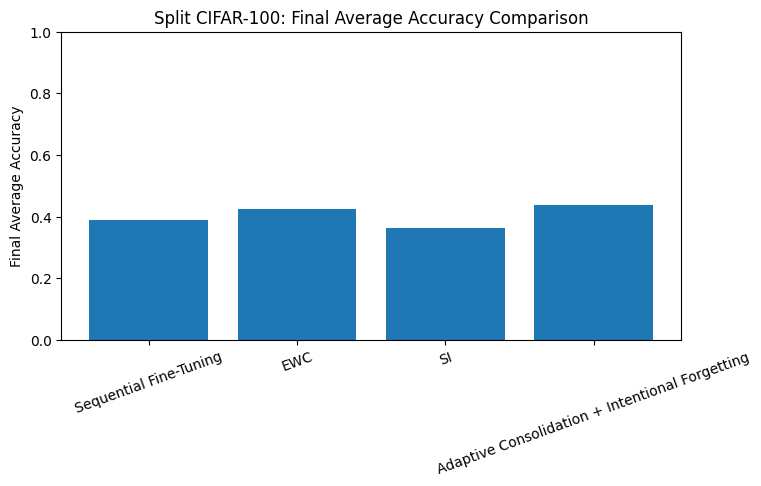

In [ ]:
# ============================================================
# CELL 21 — Plot final average accuracy
# ============================================================
labels = list(results.keys())
vals = [results[k]["Final Avg Accuracy"] for k in labels]

plt.figure(figsize=(8,4))
plt.bar(labels, vals)
plt.ylabel("Final Average Accuracy")
plt.ylim(0, 1.0)
plt.title("Split CIFAR-100: Final Average Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

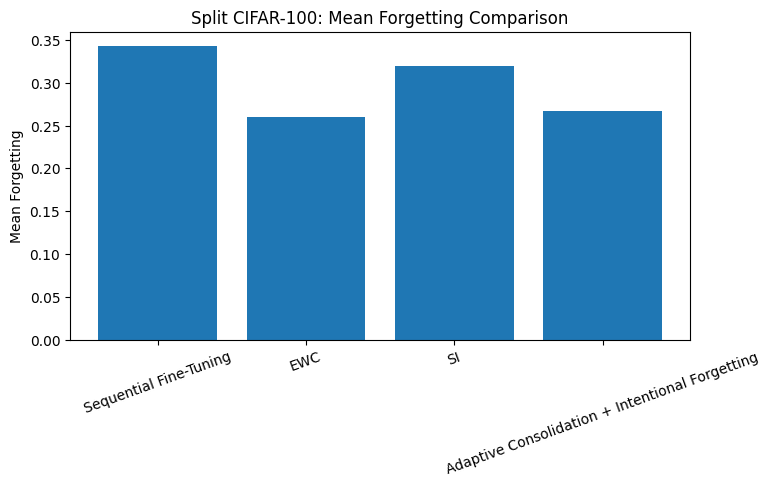

In [ ]:
# ============================================================
# CELL 22 — Plot mean forgetting
# ============================================================
labels = list(results.keys())
vals = [results[k]["Mean Forgetting"] for k in labels]

plt.figure(figsize=(8,4))
plt.bar(labels, vals)
plt.ylabel("Mean Forgetting")
plt.title("Split CIFAR-100: Mean Forgetting Comparison")
plt.xticks(rotation=20)
plt.show()

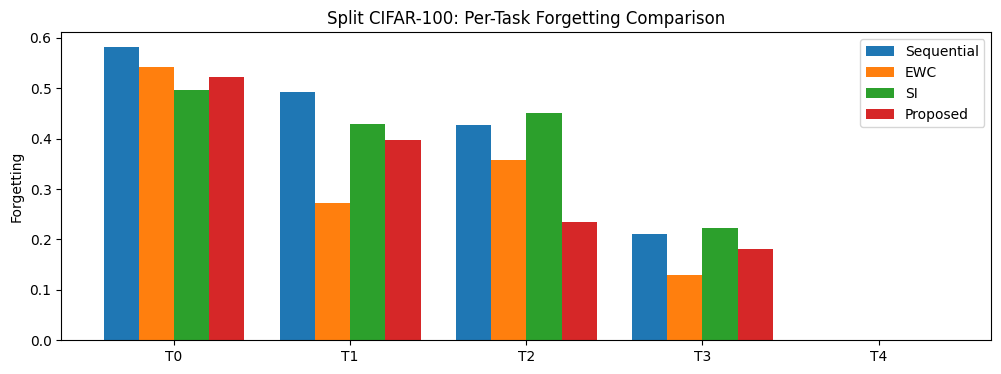

In [ ]:
# ============================================================
# CELL 23 — Per-task forgetting plot
# ============================================================
tasks = sorted(seq_forgetting_per_task.keys())

seq_vals  = [seq_forgetting_per_task[t] for t in tasks]
ewc_vals  = [ewc_forgetting_per_task[t] for t in tasks]
si_vals   = [si_forgetting_per_task[t] for t in tasks]
prop_vals = [prop_forgetting_per_task[t] for t in tasks]

x = np.arange(len(tasks))
width = 0.2

plt.figure(figsize=(12,4))
plt.bar(x - 1.5*width, seq_vals, width, label="Sequential")
plt.bar(x - 0.5*width, ewc_vals, width, label="EWC")
plt.bar(x + 0.5*width, si_vals, width, label="SI")
plt.bar(x + 1.5*width, prop_vals, width, label="Proposed")

plt.xticks(x, [f"T{t}" for t in tasks])
plt.ylabel("Forgetting")
plt.title("Split CIFAR-100: Per-Task Forgetting Comparison")
plt.legend()
plt.show()

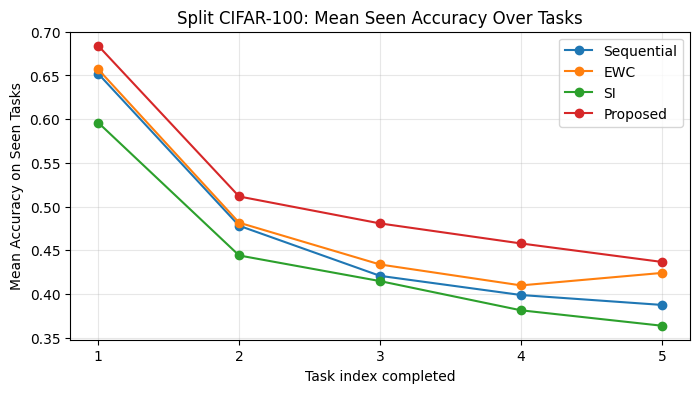

In [ ]:
# ============================================================
# CELL 24 — Mean seen accuracy trajectory
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(range(1, num_tasks + 1), seq_mean_hist, marker="o", label="Sequential")
plt.plot(range(1, num_tasks + 1), ewc_mean_hist, marker="o", label="EWC")
plt.plot(range(1, num_tasks + 1), si_mean_hist, marker="o", label="SI")
plt.plot(range(1, num_tasks + 1), prop_mean_hist, marker="o", label="Proposed")

plt.xlabel("Task index completed")
plt.ylabel("Mean Accuracy on Seen Tasks")
plt.title("Split CIFAR-100: Mean Seen Accuracy Over Tasks")
plt.xticks(range(1, num_tasks + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()